# Domača Naloga 3

## Naloga 1: Nenadzorovano učenje in predprocesiranje podatkov

### 1.a: Identifikacija povezovalnega kriterija

Spodaj so trije dendrogrami, narejeni na isti podatkovni množici, vsak z drugo funkcijo združevanja (linkage): enojno (single), celovito (complete) in Wardovo. Določi, kateri dendrogram je bil pridobljen s katero funkcijo. Vsako izbiro funkcije utemelji z vsaj eno konkretno značilnostjo dendrograma (ne zgolj z imenom funkcije ali dendrograma).

![dendrogrami](1a_dendrogrami.png)

**Vprašanji:** 
- Če bi dendrogram C odrezal/a tako, da bi dobil/a natanko tri (3) skupine, ali bi bile velikosti dobljenih skupin bolj ali manj uravnotežene kot pri istem prerezu dendrograma A? 

Velikosti dobljenih skupin bi bile bolj uravnotežene po velikosti kot pri istem prerezu dendrograma A. 
- Pojasni, zakaj Wardov kriterij teži k (po velikosti) bolj uravnoteženim skupinam.

Wardov kriterij teži k bolj uravnoteženim skupinam, ker minimizira skupno varianco znotraj skupin. Zaradi tega se pogosto združujejo manjše skupine, da se ohrani majhna varianca znotraj vsake skupine, kar vodi do bolj uravnoteženih velikosti skupin v primerjavi z drugimi metodami združevanja, kot sta enojno ali celovito združevanje.

**Pari, pojasnila in odgovora:**

Dendrogram A = single linkage (veliko združitev se zgodi pri zelo majhnih razdaljah, vidna je značilna struktura veriženja, ena manjša veja se šele pri precej večji višini združi z veliko večjo preostalo strukturo)

Dendrogram B = complete linkage (združitve se zgodijo pri večjih razdaljah, vidna je bolj kompaktna struktura, kjer se združujejo večje skupine)

Dendrogram C = Ward linkage (vidna je uravnotežena struktura skupin, združitve večjih skupin se zgodijo pri zelo visokih višinah, znotraj večjih skupin se veliko točk združi pri nizkih razdaljah, kar kaže na nizko varianco znotraj skupin)

### 1.b: Izbira števila skupin — komolec proti silhueti

Spodaj so prikazani podatki (levo), pripadajoči komolčni diagram (inercija $K$-Means glede na število skupin $K$) in graf vrednosti silhuet glede na $K$:

![izbira K](1b_k_izbira.png)

Heuristiki za izbiro števila skupin kažeta v različno smer: komolec sugerira eno vrednost $K$, silhueta drugo.

**Vprašanja:**

- Iz vsakega diagrama (komolec in silhuete) odčitaj priporočeno vrednost $K$. Pojasni, zakaj se vrednosti razhajata: kaj v strukturi teh podatkov povzroči razkorak?

Komolčni diagram priporoča K=6, saj se inercija močno zmanjšuje do K=6, po tej vrednosti pa se skoraj ne izboljšuje več. Silhuetni diagram pa priporoča K=2, ker ima pri tej vrednosti najvišjo povprečno silhueto. Razkorak nastane zato, ker imajo podatki hierarhično strukturo. V tem primeru podatki verjetno vsebujejo dve glavni skupini, ki sta dobro ločeni, kar silhuetni diagram zazna kot optimalno število skupin, medtem ko komolčni diagram vidi nadaljnje zmanjšanje variance z dodajanjem več skupin.

- Pojasni, kdaj lahko silhueta za posamezen primer postane negativna. Kaj to konkretno pove o tistem primeru in celotnem razvrščanju v skupine.

Silhueta za posamezen primer postane negativna, kadar je ta primer bolj podoben podatkom v drugi skupini kot podatkom v svoji lastni skupini. To pomeni, da je razdalja med tem primerom in povprečjem njegove skupine večja od razdalje med tem primerom in povprečjem najbližje druge skupine. Negativna silhueta torej kaže, da je ta primer verjetno napačno razvrščen in da bi se bolje ujel v drugo skupino, kar lahko nakazuje na slabo strukturo razvrščanja ali prisotnost šuma v podatkih.

- Katero vrednost $K$ bi sam/a izbral/a, če bi videl/a samo komolčni in samo silhuetni diagram (brez scatter plota diagrama podatkov)? Kaj bi naredil/a, če bi imel/a tudi scatter plot, pa bi vseeno hotel/a podpreti kvantitativno odločitev? (Namig: premisli o hierarhični strukturi, ki je prisotna pri razvrščanju teh podatkov.)

Če bi videla samo komolčni diagram, bi izbrala K=6, ker je pri K=6 jasen komolec, saj se inercija do tam močno zmanjšuje, potem pa skoraj nič več.

Če bi videla samo silhuetni diagram, bi izbrala K=2, ker ima pri tej vrednosti najvišjo povprečno silhueto. Vendar bi opazila tudi, da je K=6 zelo močan kandidat, ker ima skoraj enako visoko silhueto in izrazit lokalni maksimum.

**Odgovori:**


### 1.c: Lokalni minimumi pri K-Means

Spodaj so prikazana štiri gručenja s K-Means na isti podatkovni množici. Razlika med gručenji je nastala zgolj zaradi različnih postavitev začetnih centroidov (`init='random'`, `n_init=1`, različne nastavitve `random_state`, t.j., semena za generator naključnih števil). Naslov vsake slike vsebuje tudi inercijo (vsoto kvadratov razdalj do centroidov) za ustrezno gručenje.

![lokalni minimumi](1c_lokalne.png)

**Vprašanja:**

- Zgornja gručenja se razlikujejo. Pojasni razlike in dejstvo, da se tudi končne inercije, kljub konvergenci algoritma, medsebojno razlikujejo. Katero od štirih gručenj je glede na inercijo najboljše? Zakaj to ne pomeni, da je nujno tudi to razvrščanje prava izbira za to podatkovno množico?

Razlike med gručenji so posledica različnih začetnih postavitev centroidov, kar vodi do različnih lokalnih minimumov in s tem različnih končnih razvrščanj. K-Means je občutljiv na začetne vrednosti, zato lahko različne inicializacije privedejo do različnih rezultatov. Glede na inercijo je najboljše gručenje seed = 1, inercija = 508.5, ker ima najmanjšo inercijo. Vendar pa ni nujno, da je to razvrščanje prava izbira, ker K-Means optimizira le inercijo, kar ne zagotavlja vedno najbolj smiselne delitve podatkov. 

- V praksi `KMeans` v `sklearn` uporablja privzete nastavitve `n_init=10` in `init='k-means++'`. Razišči in pojasni, kaj _K-Means++_ počne. Zakaj v večini primerov bistveno zmanjša verjetnost slabega končnega razvrščanja?

K-Means++ je metoda za izbiro začetnih centroidov, ki poskuša izboljšati konvergenco K-Means algoritma. Namesto naključnega izbora začetnih točk, K-Means++ izbere prvi centroid naključno iz podatkov, nato pa vsak naslednji centroid izbere z verjetnostjo sorazmerno kvadratu razdalje do najbližjega že izbranega centroida. To pomeni, da se novi centroidi bolj verjetno nahajajo v delih podatkov, ki so oddaljeni od že izbranih centroidov, kar pomaga zagotoviti boljšo pokritost podatkov in zmanjšuje verjetnost, da bodo vsi začetni centroidi blizu skupaj, kar lahko vodi do slabih lokalnih minimumov.

- Konstruiraj (ali besedno opiši) majhno podatkovno množico, kjer tudi K-Means++ z visokim `n_init` še vedno (v večini primerov) ne najde prave rešitve. Kakšna struktura podatkov to povzroči? (Namig: o teh primerih smo govorili tudi na vajah.)

Primer so koncentrični krogi. Podatke imamo v dveh skupinah; notranji krog točk okoli središča in zunanji krog točk okoli istega središča. Prava razvrstitev bi bila, da bi notranji krog bil ena skupina, zunanji krog pa druga skupina. Toda K-Means s K=2 tega običajno ne bo našel. Namesto tega bo pogosto razdelil podatke na “levo polovico” in “desno polovico”, ker K-Means dela z linearno centroidno razdelitvijo prostora. Vsaka skupina je območje okoli centroida. Pri koncentričnih krogih pa imata obe pravi skupini približno isti center. Notranji in zunanji krog nista ločena z ravno mejo, ampak z ukrivljeno krožno mejo. To je struktura, ki je K-Means ne zna dobro modelirati. V takih primerih tudi K-Means++ z veliko ponovitvami lahko najde dobro rešitev glede inercije, vendar še vedno napačno rešitev glede dejanske strukture podatkov.

- Predlagaj dve rešitvi, ki bi pravilno gručila podatke na zgornji sliki.

Za podatke na sliki bi predlagali metode, ki bolje obravnavajo podolgovate skupine.

Rešitev 1: DBSCAN (Density-Based Spatial Clustering of Applications with Noise) ali ali HDBSCAN (Hierarchical DBSCAN) je metoda, ki združuje točke glede na gostoto. DBSCAN lahko najde skupine poljubne oblike, vključno s podolgovatimi in nepravilnimi skupinami, saj ne temelji na konceptu centroidov ali linearnih delitev prostora. DBSCAN bi lahko pravilno prepoznal vsako diagonalno skupino, če med njimi obstajajo dovolj jasne praznine. Za zgornjo sliko je to dobra izbira, ker so naravne skupine videti kot goste diagonalne strukture.

Rešitev 2: Spektralno gručenje (Spectral Clustering) je metoda, ki uporablja lastne vrednosti matrike sosednosti podatkov za zmanjšanje dimenzionalnosti in nato izvaja K-Means v tem zmanjšanem prostoru. Spektralno gručenje lahko prav tako obravnava kompleksne oblike skupin, saj temelji na povezavah med podatki namesto na njihovih absolutnih položajih. Za zgornjo sliko bi spektralno gručenje lahko pravilno združilo točke v vsako diagonalno skupino, ker bi zajelo njihovo povezanost, ne glede na njihovo linearno porazdelitev.



**Odgovori:**

### 1.d: Prekletstvo večrazsežnosti

Spodaj so prikazane porazdelitve evklidskih razdalj med vsemi pari $n = 300$ naključno (enakomerno) vzorčenih točk v $[0,1]^d$ za tri različne dimenzionalnosti prostora $d \in \{2,\ 20,\ 500\}$:

![curse of dim](1d_kletev.png)

V naslovih slik sta navedena povprečje in standardni odklon razdalj ter njuno razmerje $\text{std} / \text{povp}$.

**Vprašanja:**

- Z rastjo razsežnosti prostora, vrednost razmerje $\text{std}/\text{povp}$ strmo pada (s $\sim 0.48$ pri $d=2$ na $\sim 0.03$ pri $d=500$). Pojasni intuitivno, zakaj se to zgodi.

V nizki dimenziji, na primer pri d=2, sta dve naključni točki v kvadratu $[0,1]^2$ lahko zelo različno oddaljeni, saj sta lahko skoraj na istem mestu ali pa na nasprotnih kotih kvadrata. Zato so razdalje precej razpršene. V visoki dimenziji pa je evklidska razdalja sestavljena iz zelo veliko majhnih prispevkov po posameznih koordinatah. Ko je d velik, je ta vsota povprečje oziroma seštevek veliko podobnih naključnih prispevkov. Zaradi zakona velikih števil se skupni rezultat stabilizira in posamezne razlike po koordinatah se “izpovprečijo”. Tako postanejo razdalje med točkami v visokih dimenzijah zelo podobne, kar vodi do majhnega standardnega odklona v primerjavi s povprečjem, in s tem padajočega razmerja $\text{std}/\text{povp}$.

- Kako ta pojav vpliva na algoritmih K-Means, DBSCAN in klasifikacijo s KNN v zelo visokorazsežnostnih prostorih? Za vsakega od treh algoritmov identificiraj konkretno komponento, ki v teh prostorih postane praktično neuporabna in pojasni zakaj je temu tako.
K-Means: V visokih dimenzijah postane evklidska razdalja med točkami zelo podobna, kar pomeni, da K-Means težko razlikuje med različnimi skupinami. Komponenta, ki postane neuporabna, je izbira najbližjega centroida, saj so vsi centroidi približno enako oddaljeni od vsake točke, kar vodi do slabega razvrščanja.

DBSCAN: DBSCAN temelji na konceptu gostote. Za vsako točko pogleda, koliko drugih točk je znotraj razdalje $\epsilon$. V visokih dimenzijah postanejo razdalje med točkami podobne, kar pomeni, da DBSCAN težko razlikuje med gostimi in redkimi območji. DBSCAN zato težko najde smiselno vrednost $\epsilon$. V nizkih dimenzijah lahko obstajajo jasna gosta območja in praznine med njimi. V visokih dimenzijah pa zaradi koncentracije razdalj lokalna gostota pogosto ni več dobro razvidna.

KNN: KNN klasifikacija temelji na iskanju najbližjih sosedov. V visokih dimenzijah postanejo vsi sosedi približno enako oddaljeni, kar pomeni, da KNN težko razlikuje med različnimi razredi. Komponenta, ki postane neuporabna, je izbira najbližjih sosedov, saj so vsi sosedi približno enako oddaljeni od testne točke, kar vodi do slabše klasifikacije.

- Pogosta strategija pred razvrščanjem visokorazsežnostnih podatkov je uporaba algoritmov za krčenje razsežnosti kot je PCA (npr. iz 500D v 10D), nato pa razvrščanje v skupine v skrčenem (nizkorazsežnostnem) podatkovnem prostoru. Pojasni kdaj taka strategija pomaga (kakšne so značilnosti podatkov, kjer PCA odkrije pravo strukturo) in kdaj škoduje (kjer PCA struktur, pomembnih za razvrščanje v skupine, ne najde).

Taka strategija pomaga, kadar so podatki v visokih dimenzijah dejansko zgoščeni okoli nižje dimenzionalnih struktur, kot so linearne kombinacije originalnih dimenzij. Na primer, če so podatki v 500D dejansko le na 10D podprostoru, potem bo PCA lahko učinkovito zajel to strukturo in omogočil uspešno razvrščanje v skupine v skrčenem prostoru. PCA je dobra izbira, kadar je struktura podatkov približno linearna ali večina pomembne variance leži v prvih glavnih komponentah ali pa je veliko dimenzij šumnih. PCA ohrani razdalje, ki so pomembne za gručenje. V takem primeru PCA odstrani šum in ohrani koristno strukturo. Potem lahko K-Means, DBSCAN ali drugi algoritmi delujejo bolje, ker razdalje v 10D prostoru spet postanejo bolj informativne.
PCA lahko škoduje, kadar struktura, ki ločuje skupine, ni v smereh največje variance. PCA je nenadzorovana metoda, ki ne išče skupin. Išče samo smeri, kjer imajo podatki največjo varianco. Zato lahko PCA zavrže dimenzije, ki imajo majhno varianco, a so ključne za ločevanje skupin. 

**Odgovori:**

## Naloga 2: Izbira napovednih spremenljivk z algoritmom ReliefF

V tej nalogi boš implementiral/a algoritem ReliefF, ki oceni pomembnost (napovedno moč) napovednih spremenljivk z analizo najbližjih sosedov: tistih z isto vrednostjo ciljne spremenljivke (*nearest hits*) in tistih z različno vrednostjo ciljne spremenljivke (*nearest misses*). Logična predpostavka algoritma je, da dobra napovedna spremenljivka ima podobne vrednosti v primerih z isto vrednostjo ciljne spremenljivke in zelo različne vrednosti v primerih z različno vrednostjo ciljne spremenljivke.

ReliefF je razširitev osnovnega algoritma Relief za večrazredne probleme (probleme kjer je domena $D_Y$ ciljne spremenljivke $Y$ taka, da velja $|D_Y| > 2$) in z večjo odpornost na šum. ReliefF namesto enega najbližjega upošteva $k$ najbližjih sosedov, pri *nearest misses* pa povpreči preko vseh vrednostih ciljne spremenljivke, ki se razlikujejo od vrednosti ciljne spremenljivke opazovanega primera, z utežmi glede na porazdelitev vrednosti ciljne spremenljivke v učni množici.

### 2.a: Razdalja po spremenljivkah

Preden lahko iščemo najbližje sosede, moramo definirati, kako merimo razdaljo med dvema primeroma po posamezni spremenljivki. ReliefF razdaljo definira različno glede na tip spremenljivke:

- numerična: $\text{diff}(f, x_1, x_2) = \dfrac{|x_1^{(f)} - x_2^{(f)}|}{\max(f) - \min(f)}$
- kategorična: $\text{diff}(f, x_1, x_2) = \begin{cases} 0 & \text{če } x_1^{(f)} = x_2^{(f)} \\ 1 & \text{sicer} \end{cases}$,

kjer $f$ je oznaka spremenljivke, $\max{f}$ in $\min{f}$ sta maksimalna in minimalna vrednost te spremenljivke, $x_1$ in $x_2$ sta primera, ter $x^{(f)}$ je vrednost spremenljivke $f$ v primeru $x$.

Dopolni funkcijo `diff`, ki za podana primera vrne vektor njunih razdalj po vseh spremenljivkah. Skupno razdaljo med primeroma bomo kasneje računali kot vsoto (ali $\ell_1$ normo) tega vektorja.

**Vprašanje:** Zakaj numerične spremenljivke normaliziramo?

Numerične spremenljivke normaliziramo zato, da imajo vse približno primerljiv vpliv na razdaljo. Brez normalizacije bi lahko spremenljivka z velikim razponom vrednosti prevladala nad ostalimi.

In [1]:
import numpy as np

def diff(x1, x2, feature_ranges, categorical_mask):
    """
    Izračuna razdaljo med primeroma x1 in x2 po vsaki spremenljivki posebej.
    """
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    feature_ranges = np.asarray(feature_ranges)
    categorical_mask = np.asarray(categorical_mask)

    # pripravimo rezultat
    d = np.zeros_like(x1, dtype=float)

    # kategorične spremenljivke: 0, če sta vrednosti enaki, 1 sicer
    d[categorical_mask] = (x1[categorical_mask] != x2[categorical_mask]).astype(float)

    # numerične spremenljivke: absolutna razlika / razpon
    numeric_mask = ~categorical_mask

    # če ima katera numerična spremenljivka razpon 0 (da ne delimo z 0)
    safe_ranges = feature_ranges[numeric_mask].copy()
    safe_ranges[safe_ranges == 0] = 1.0

    d[numeric_mask] = np.abs(x1[numeric_mask] - x2[numeric_mask]) / safe_ranges

    return d


# Test
x1 = np.array([0.0, 1.0, 0.0])
x2 = np.array([1.0, 0.0, 1.0])
x3 = np.array([0.5, 1.0, 0.0])
ranges = np.array([1.0, 1.0, 1.0])
cat_mask = np.array([False, True, True])

print(diff(x1, x2, ranges, cat_mask))  # pričakovano: [1.0, 1.0, 1.0]
print(diff(x1, x3, ranges, cat_mask))  # pričakovano: [0.5, 0.0, 0.0]

[1. 1. 1.]
[0.5 0.  0. ]


### 2.b: ReliefF — najbližji zadetki in zgrešitve

Za vsak naključno izbran primer $R$ s ciljno vrednostjo (vrednostjo ciljne spremenljivke) $y(R)$ poiščemo njegove najbližje sosede:
- najbližje zadetke (*nearest hits*) — $k$ najbližjih primerov z isto ciljno vrednostjo kot $R$,
- najbližje zgrešitve (*nearest misses*) — $k$ najbližjih primerov iz vsake druge vrednosti ciljne spremenljivke, ki ni enaka ciljni vrednosti primera $R$.

Ideja posodobitve uteži je naslednja: če ima spremenljivka pri zadetkih majhno razdaljo (kar je dobro!) in pri zgrešitvah veliko razdaljo (tudi dobro!), se njena utež poveča. Pri zgrešitvah iz različnih razredov računamo obteženo povprečje z utežmi glede na apriorne verjetnosti ciljne spremenljivke $P(C)$, ker želimo redke in pogoste razrede obravnavati sorazmerno. Posodobitev uteži definira naslednji predpis:

$$w_f \leftarrow w_f - \frac{1}{m \cdot k}\sum_{j=1}^{k}\text{diff}(f, R, H_j) + \frac{1}{m \cdot k}\sum_{C \neq y(R)}\frac{P(C)}{1 - P(y(R))}\sum_{j=1}^{k}\text{diff}(f, R, M_j(C))$$

kjer so $H_j$ za $j = 1, 2, \dots, k$, najbližji zadetki, $M_j(C)$ za $j = 1, 2, \ldots, k$ najbližje zgrešitve iz razreda $C$ in $m$ število iteracij, ki je enako številu izbranih primerov $R$. Skupno razdaljo med dvema primeroma (za iskanje najbližjih sosedov) izračunaj kot vsoto vektorja `diff` po vseh spremenljivkah.

Dopolni funkcijo `relieff` tako, da bo implementirala zgoraj opisan pristop.

**Vprašanji:**

- Zakaj povprečenje preko $k$ sosedov poveča robustnost na šum v oznakah? Zakaj zgrešitve iz različnih razredov utežimo z njihovimi apriornimi verjetnostmi in kaj bi se zgodilo, če bi vse razrede obravnavali enako, ne glede na to, koliko primerov pripada vsakemu?

Osnovni Relief uporablja samo enega najbližjega zadetka in enega najbližjega zgreška. To je lahko občutljivo na šum. Če je najbližji sosed slučajno napačno označen, zelo netipičen ali leži na meji med razredi, lahko močno pokvari posodobitev uteži. ReliefF zato uporabi k najbližjih zadetkov in k najbližjih zgrešitev. S tem posamezen slab sosed nima več tako velikega vpliva, ker se njegov vpliv povpreči z ostalimi. Namesto da bi odločal en primer, odločata lokalna okolica in povprečno vedenje več podobnih primerov.

Pri večrazrednem problemu ima primer R lahko zgrešitve iz več različnih razredov. Če bi vsak drugi razred obravnavali enako, bi redki razredi dobili nesorazmerno velik vpliv.

- ReliefF je razširitev osnovnega Relief algoritma. Pod kakšnimi pogoji in konfiguracijo bo ReliefF deloval enako kot Relief — brez kakršnih koli sprememb kode?

ReliefF bo deloval enako kot Relief, če nastavimo $k=1$ in imamo samo dve vrednosti ciljne spremenljivke. V tem primeru bo ReliefF za vsak izbran primer $R$ poiskal samo ene najbližji zadetek (ki je enak kot $R$) in samo eno najbližjo zgrešitev (ki je drugačna od $R$). Prav tako, ker imamo samo dva razreda, ne bo potrebe po uteževanju z apriornimi verjetnostmi, saj bo obstajala le ena druga vrednost ciljne spremenljivke. Zato se bo posodobitev uteži izvajala na enak način kot v osnovnem Relief algoritmu.

In [2]:
import numpy as np

def relieff(X, y, n_iterations, k, feature_ranges, categorical_mask, rng=None):
    """
    ReliefF algoritem za večrazredno klasifikacijo.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    n, p = X.shape
    weights = np.zeros(p, dtype=float)

    if rng is None:
        rng = np.random.default_rng()

    classes, counts = np.unique(y, return_counts=True)
    priors = {c: count / n for c, count in zip(classes, counts)}

    # naključno izbrani primeri R
    chosen_indices = rng.integers(0, n, size=n_iterations)

    for idx in chosen_indices:
        R = X[idx]
        y_R = y[idx]

        # razdalje od R do vseh drugih primerov
        distances = np.zeros(n, dtype=float)

        for i in range(n):
            if i == idx:
                distances[i] = np.inf
            else:
                distances[i] = diff(R, X[i], feature_ranges, categorical_mask).sum()
                
        # nearest hits
        hit_candidates = np.where((y == y_R) & (np.arange(n) != idx))[0]
        nearest_hits = hit_candidates[np.argsort(distances[hit_candidates])[:k]]

        if len(nearest_hits) > 0:
            hit_diffs = np.array([
                diff(R, X[h], feature_ranges, categorical_mask)
                for h in nearest_hits
            ])

            weights -= hit_diffs.mean(axis=0) / n_iterations

        # nearest misses
        for C in classes:
            if C == y_R:
                continue

            miss_candidates = np.where(y == C)[0]
            nearest_misses = miss_candidates[np.argsort(distances[miss_candidates])[:k]]

            if len(nearest_misses) == 0:
                continue

            miss_diffs = np.array([
                diff(R, X[m], feature_ranges, categorical_mask)
                for m in nearest_misses
            ])

            class_weight = priors[C] / (1 - priors[y_R])

            weights += class_weight * miss_diffs.mean(axis=0) / n_iterations

    return weights

# Test na večrazrednem primeru
rng = np.random.default_rng(42)
n = 300
X_test = rng.normal(0, 1, (n, 4))
y_test = rng.integers(0, 3, n)
X_test[:, 0] += 2 * y_test  # samo prva spremenljivka loči razrede

ranges = X_test.max(axis=0) - X_test.min(axis=0)
cat_mask = np.array([False, False, False, False])

weights = relieff(X_test, y_test, n_iterations=300, k=10,
                  feature_ranges=ranges, categorical_mask=cat_mask,
                  rng=np.random.default_rng(0))
print("Uteži:", weights)
print("Najpomembnejša spremenljivka:", np.argmax(weights), "(pričakovano: 0)")

Uteži: [0.1330804  0.00045885 0.0052478  0.00525919]
Najpomembnejša spremenljivka: 0 (pričakovano: 0)


### 2.c: Primerjava na neuravnoteženi večrazredni množici

Sestavili bomo umetno trirazredno množico, kjer ciljna spremenljivka $y$ predstavlja tri neuravnotežene razrede (apriorne verjetnosti razredov so $P(0) = 0.7$, $P(1) = 0.2$, $P(2) = 0.1$) in ima tri numeričnime spremenljivke:
- $F_1$: informativna — njena povprečna vrednost je odvisna od razreda, t.j., vrednosti $y$ ($0$, $1.5$, $3$ pri razredih $0$, $1$, $2$);
- $F_2$: nepovezana z $y$, a ima visoko varianco ($\mathcal{N}(0, 5^2)$);
- $F_3$: nepovezana z $y$, z nizko varianco ($\mathcal{N}(0, 0.01^2)$).

Na teh podatkih primerjaj tri pristope za ocenjevanje napovedne moči spremenljivk:
1. Varianca, ki meri varianco spremenljivke;
2. Vzajemna informacija (`sklearn.feature_selection.mutual_info_classif`), ki meri medsebojno informacijo med podano napovedno spremenljivko in $y$;
3. ReliefF.

Nariši stolpčni diagram ocen za vsak pristop (en subplot na pristop) ter primerjaj in komentiraj rezultate.

**Vprašanja:**

- Kaj je razlog, da varianca slabo napove pravo napovedno moč spremenljivk?

Varianca slabo napove pravo napovedno moč spremenljivk, ker meri le razpršenost vrednosti spremenljivke, ne pa njene povezave s ciljno spremenljivko. Spremenljivka $F_2$ ima visoko varianco, vendar ni povezana z $y$, zato bo imela visoko oceno po varianci, kljub temu da nima napovedne moči. Po drugi strani pa $F_3$ ima nizko varianco, vendar prav tako ni povezana z $y$, zato bo imela nizko oceno po varianci. Varianca ne upošteva, ali so vrednosti spremenljivke informativne glede na ciljno spremenljivko, kar je ključni dejavnik za napovedno moč.

- Izberi pristop, ki se ti zdi na tej množici najboljši in pojasni, kako si ta pristop izbral. So na izbiro vplivale izračunane vrednosti, razmerja med temi vrednostmi ali kaj tretjega?

Najboljši pristop na tej množici se mi zdi ReliefF. Izbrala sem ga, ker upošteva tako podobnosti med primeri z isto ciljno vrednostjo (nearest hits) kot tudi razlike med primeri z različnimi ciljnimi vrednostmi (nearest misses). To pomeni, da bo ReliefF lahko pravilno ocenil $F_1$ kot najbolj informativno spremenljivko, saj bo opazil, da imajo primeri z isto vrednostjo $y$ podobne vrednosti $F_1$, medtem ko imajo primeri z različnimi vrednostmi $y$ različne vrednosti $F_1$. Vzajemna informacija bi prav tako lahko prepoznala $F_1$ kot najbolj informativno, vendar ReliefF dodatno upošteva lokalno strukturo podatkov, kar mu daje prednost v tem primeru. Varianca pa je popolnoma neinformativna v tem primeru, saj ne meri povezave s ciljno spremenljivko.

- Pri tej množici je razred $2$ redek (le $10\%$ primerov). Razmisli, kaj bi se zgodilo z utežmi `relieff`, če bi v posodobitveni formuli odstranili faktor $P(C)/(1 - P(y(R)))$ in vse razrede zgrešitev obteževali enako. Bi bila ocena $F_1$ takrat višja, nižja ali približno enaka — in zakaj?

Če bi odstranili faktor $P(C)/(1 - P(y(R)))$ in vse razrede zgrešitev utežili enako, bi redki razred $2$ dobil nesorazmerno velik vpliv. Ker je razred $2$ po spremenljivki $F_1$ najbolj oddaljen od razreda $0$, bi to pri večinskih primerih iz razreda $0$ povečalo povprečno razliko do zgrešitev. Zato bi bila ocena $F_1$ verjetno višja. To ne pomeni, da je taka ocena boljša, ampak da metoda ne bi več pravilno upoštevala dejanske porazdelitve razredov.

Variance: [1.96368328e+00 2.64332651e+01 1.03271487e-04]
Mutual information: [0.35150981 0.         0.        ]
ReliefF: [0.09050838 0.02210423 0.01944885]


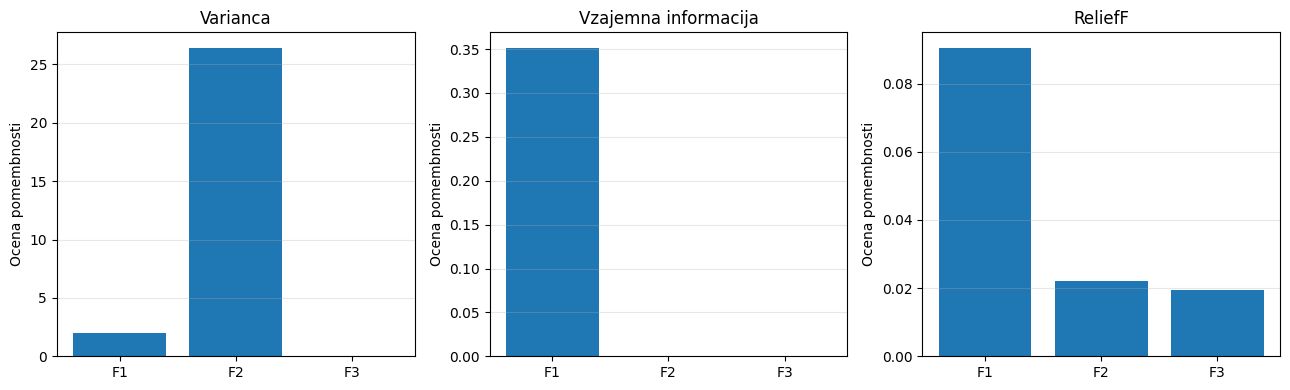

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

rng = np.random.default_rng(0)
n = 600
class_probs = [0.7, 0.2, 0.1]
y_data = rng.choice(3, size=n, p=class_probs)

class_means = np.array([0.0, 1.5, 3.0])
F1 = rng.normal(0, 1, n) + class_means[y_data]   # informativna, ločuje razrede
F2 = rng.normal(0, 5, n)                         # visoka varianca, neinformativna
F3 = rng.normal(0, 0.01, n)                      # nizka varianca, neinformativna

X_data = np.column_stack([F1, F2, F3])

feature_names = ["F1", "F2", "F3"]

# 1. Varianca
variance_scores = X_data.var(axis=0)

# 2. Vzajemna informacija
mi_scores = mutual_info_classif(
    X_data,
    y_data,
    discrete_features=False,
    random_state=0
)

# 3. ReliefF
ranges = X_data.max(axis=0) - X_data.min(axis=0)
cat_mask = np.array([False, False, False])

relieff_scores = relieff(
    X_data,
    y_data,
    n_iterations=600,
    k=10,
    feature_ranges=ranges,
    categorical_mask=cat_mask,
    rng=np.random.default_rng(0)
)

print("Variance:", variance_scores)
print("Mutual information:", mi_scores)
print("ReliefF:", relieff_scores)

# Stolpčni diagrami
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

scores_list = [variance_scores, mi_scores, relieff_scores]
titles = ["Varianca", "Vzajemna informacija", "ReliefF"]

for ax, scores, title in zip(axes, scores_list, titles):
    ax.bar(feature_names, scores)
    ax.set_title(title)
    ax.set_ylabel("Ocena pomembnosti")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 2.d: Past interakcije — podatkovna množica XOR s štirimi spremenljivkami

Sestavimo sedaj bolj zahtevno podatkovno množico s štirimi napovednimi spremenljivkami:
- $F_1, F_2$: vsaka posebej je čisti šum ($\mathcal{N}(0, 1)$), a skupaj preko XOR vzorca popolnoma določita vrednost ciljne spremenljivke $y$ tako, da velja $y = 1$ natanko tedaj, ko sta $F_1$ in $F_2$ istega predznaka.
- $F_3$: neinformativni šum z visoko varianco.
- $F_4$: neinformativni šum z nizko varianco.

Na tej podatkovni množici ponovno poženi vse tri metode iz 2.c in vizualiziraj rezultate.

**Vprašanji:** 

- Zakaj pri ocenjevanju napovednih moči spremenljivk $F_1$ in $F_2$ odpove varianca in zakaj odpove vzajemna informacija?

Varianca odpove, ker $F_1$ in $F_2$ vsaka posebej nimata nobene variance, ki bi bila informativna glede na ciljno spremenljivko $y$. Vsaka od teh spremenljivk je čisti šum, zato bo imela nizko varianco, kar vodi do nizke ocene po varianci. Vzajemna informacija odpove, ker $F_1$ in $F_2$ vsaka posebej nimata nobene informacije o $y$. Vzajemna informacija meri povezavo med posamezno spremenljivko in ciljno spremenljivko, vendar v tem primeru nobena od spremenljivk sama po sebi ne vsebuje informacije o $y$, saj je informacija skrita v interakciji med njima. Zato bo vzajemna informacija za obe spremenljivki nizka.

- Opiši zakaj ReliefF napovednih moči spremenljivk $F_1$ in $F_2$ lahko prepozna oziroma identificiraj in opiši prednost tega pristopa pred drugima dvema.

ReliefF lahko prepozna napovedno moč spremenljivk $F_1$ in $F_2$, ker upošteva lokalno strukturo podatkov in interakcije med spremenljivkami. Ko izbere primer $R$, bo poiskal najbližje zadetke (nearest hits) z isto vrednostjo ciljne spremenljivke $y$ in najbližje zgrešitve (nearest misses) z različnimi vrednostmi $y$. V tem primeru bodo primeri z isto vrednostjo $y$ imeli podobne vrednosti za $F_1$ in $F_2$, medtem ko bodo primeri z različnimi vrednostmi $y$ imeli različne vrednosti za ti dve spremenljivki. Zato bo ReliefF zaznal, da imata $F_1$ in $F_2$ pomembno vlogo pri ločevanju razredov, kljub temu da vsaka posebej ni informativna. To je prednost ReliefF pred varianco in vzajemno informacijo, ki ne upoštevata interakcij med spremenljivkami.

Variance: [1.02738378e+00 8.79815254e-01 2.55108663e+01 1.06456838e-04]
Mutual information: [0.00384259 0.         0.04347423 0.00713294]
ReliefF: [ 0.05117985  0.04629036 -0.00590931 -0.00815185]


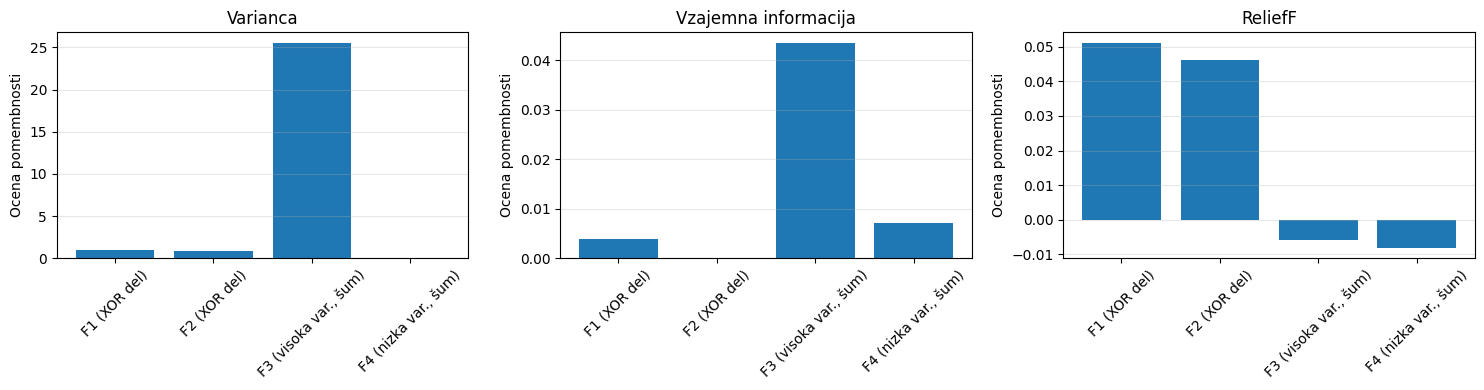

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

rng = np.random.default_rng(0)
n = 500

F1 = rng.normal(0, 1, n)
F2 = rng.normal(0, 1, n)

y_data = ((F1 * F2) > 0).astype(int)  # 1, če sta istega predznaka

F3 = rng.normal(0, 5, n)              # visoka varianca, neinformativna
F4 = rng.normal(0, 0.01, n)           # nizka varianca, neinformativna

X_data = np.column_stack([F1, F2, F3, F4])

feature_names = [
    "F1 (XOR del)",
    "F2 (XOR del)",
    "F3 (visoka var., šum)",
    "F4 (nizka var., šum)"
]

# 1. Varianca
variance_scores = X_data.var(axis=0)

# 2. Vzajemna informacija
mi_scores = mutual_info_classif(
    X_data,
    y_data,
    discrete_features=False,
    random_state=0
)

# 3. ReliefF
ranges = X_data.max(axis=0) - X_data.min(axis=0)
cat_mask = np.array([False, False, False, False])

relieff_scores = relieff(
    X_data,
    y_data,
    n_iterations=500,
    k=10,
    feature_ranges=ranges,
    categorical_mask=cat_mask,
    rng=np.random.default_rng(0)
)

print("Variance:", variance_scores)
print("Mutual information:", mi_scores)
print("ReliefF:", relieff_scores)

# Vizualizacija
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

scores_list = [variance_scores, mi_scores, relieff_scores]
titles = ["Varianca", "Vzajemna informacija", "ReliefF"]

for ax, scores, title in zip(axes, scores_list, titles):
    ax.bar(feature_names, scores)
    ax.set_title(title)
    ax.set_ylabel("Ocena pomembnosti")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### 2.e: Razprava

Odgovori na naslednji vprašanji:

1. Predstavljaj si, da podatkovni množici iz 2.d dodaš spremenljivko $F_5$, ki je natančna (ali skoraj natančna) kopija spremenljivke $F_1$. Kakšne uteži pričakuješ od ReliefF za $F_1$ in $F_5$? Je to dobro ali slabo za izbiro spremenljivk, če želimo na koncu uporabiti čim manj spremenljivk?

Če dodamo spremenljivko $F_5$, ki je natančna ali skoraj natančna kopija $F_1$, pričakujem, da bo ReliefF dodelil podobne uteži obema spremenljivkama, saj bosta imeli enako informativno vrednost glede na ciljno spremenljivko $y$. To ni nujno slabo za izbiro spremenljivk, saj obe spremenljivki vsebujeta enako informacijo. Vendar pa je pa to lahko slabo, če želimo na koncu uporabiti čim manj spremenljivk. $F_5$ ne prinese nove informacije, ker je samo kopija $F_1$. V takem primeru bi bilo smiselno odstraniti eno od teh dveh spremenljivk (na primer $F_5$), da bi zmanjšali število spremenljivk brez izgube napovedne moči.

2. Kdaj (v kakšnih primerih) bi izbral vsakega od treh pristopov iz naloge 2.c?

- Varianca: Ta pristop bi izbrala, kadar želim hitro in enostavno merilo za oceno napovedne moči spremenljivk, in kadar sumim, da so pomembne spremenljivke tiste z visoko varianco. To je lahko uporabno kot prvi korak pri analizi podatkov, vendar ni priporočljivo kot edini kriterij za izbiro spremenljivk.Primerna je, kadar želimo odstraniti spremenljivke, ki se skoraj nič ne spreminjajo, na primer skoraj konstantne spremenljivke. Take spremenljivke pogosto niso koristne, ker imajo pri skoraj vseh primerih enako vrednost.
- Vzajemna informacija: Vzajemno informacijo bi izbrala, kadar želim oceniti, ali je posamezna spremenljivka sama po sebi povezana s ciljno spremenljivko. Vzajemna informacija je dobra izbira, kadar sumim, da so pomembne spremenljivke tiste, ki imajo močno povezavo z $y$, ne glede na to, ali je ta povezava linearna ali nelinearna. Vendar ne upošteva interakcij med spremenljivkami, zato ni najboljša izbira, kadar sumim, da so pomembne interakcije.
- ReliefF: ReliefF bi izbrala, kadar sumim, da so pomembne interakcije med spremenljivkami ali lokalna struktura podatkov. ReliefF je najboljša izbira, kadar sumim, da so pomembne spremenljivke tiste, ki imajo podobne vrednosti v primerih z isto vrednostjo $y$ in različne vrednosti v primerih z različnimi vrednostmi $y$. ReliefF je robusten na šum in lahko prepozna pomembne spremenljivke tudi v prisotnosti nepovezanih spremenljivk z visoko varianco, kar je velika prednost v realnih podatkovnih množicah.

## Naloga 3: Nelinearno krčenje razsežnosti in neuravnotežene množice

V tej nalogi se bomo hkrati soočali z dvema povezanima problemoma. Najprej bomo skrčili razsežnost podatkov s samokodirnikom in primerjali rezultate s PCA. Nato pa bomo vizualno ugotavljali, kako SMOTE vzorči nove primere in s tem pomaga pri uravnoteževanju porazdelitve vrednosti ciljne spremenljivke.

Za podatke bomo uporabili sklearnov `load_digits` — 1797 ročno napisanih števk velikosti $8 \times 8$ pikslov (64 napovednih spremenljivk).

### 3.a: Samokodirnik

Samokodirnike že poznaš z vaj — tukaj jih bomo uporabili kot nelinearno alternativo metodi analize glavnih komponent (PCA). Spomnimo se ključne razlike med PCA in samokodirnikom. Če sta kodirnik in dekodirnik linearna, samokodirnik preslika podatke v latentni nizkorazsežnostni prostor tako kot PCA. Z uporabo nelinearnih funkcij aktivacije v kodirniku in dekodirniku, se lahko samokodirnik nauči primere nelinearno transformirati v latentni prostor. Ta nelinearna transformacija je bistvo te naloge.

Dopolni razred `Autoencoder`, tako da bo implementiral kodirnik z arhitekturo `input_dim → 32 → 16 → latent_dim` in dekodirnik z zrcalno arhitekturo. V vseh plasteh, razen izhodni plasti dekodirnika, uporabi `nn.Tanh()`. V izhodni plasti dekodirnika pa uporabi `nn.Sigmoid()` (zato, da bodo vrednosti pikslov v intervalu $[0, 1]$).

In [5]:
import torch
import torch.nn as nn


class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()

        # Kodirnik: input_dim -> 32 -> 16 -> latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 16),
            nn.Tanh(),
            nn.Linear(16, latent_dim),
            nn.Tanh()
        )

        # Dekodirnik: latent_dim -> 16 -> 32 -> input_dim
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.Tanh(),
            nn.Linear(16, 32),
            nn.Tanh(),
            nn.Linear(32, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z


def train_autoencoder(model, X, n_epochs=3000, lr=2e-3, verbose=True):
    """Učenje samokodirnika z MSE izgubo in Adam optimizatorjem."""

    # Če je X numpy tabela, jo pretvorimo v torch tensor
    if not torch.is_tensor(X):
        X = torch.tensor(X, dtype=torch.float32)
    else:
        X = X.float()

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(n_epochs):
        model.train()

        optimizer.zero_grad()

        x_rec, z = model(X)
        loss = criterion(x_rec, X)

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, loss = {loss.item():.6f}")

    return losses


# Hiter test
torch.manual_seed(0)
ae_test = Autoencoder(input_dim=64, latent_dim=2)
x_test = torch.rand(5, 64)
x_rec, z = ae_test(x_test)
print("Vhod:", x_test.shape, "→ latentni:", z.shape, "→ rekonstrukcija:", x_rec.shape)

Vhod: torch.Size([5, 64]) → latentni: torch.Size([5, 2]) → rekonstrukcija: torch.Size([5, 64])


### 3.b: Števke — PCA vs. samokodirnik

Naložimo podatkovno množico `sklearn.datasets.load_digits` in normalizirajmo vrednosti pikslov (napovednih spremenljivk) na interval $[0, 1]$ (delimo s 16, ker so vrednosti pikslov v intervalu $[0, 16]$).

Naredi naslednje:
1. Prikaži nekaj primerov števk (npr. po eno iz vsakega razreda).
2. Uporabi PCA za preslikavo podatkovne množice v dvodimenzionalni prostor.
3. Natreniraj samokodirnik z `latent_dim=2` in pridobi njegove dvodimenzionalne predstavitve primerov iz učne množice v latentnem prostoru.
4. Za vsako od teh dveh predstavitev nariši scatterplot enega ob drugem, kjer so točke pobarvane na osnovi števk, ki jih predstavljajo.

**Vprašanji:**
- Katera metoda bolje loči skupine primerov po razredih (števkah) in zakaj? Premisli kolikšno je najmanjše število komponent PCA, ki bi jih potrebovali zato, da dobro ločimo števke (razrede).

V 2D prostoru samokodirnik bolje loči skupine primerov po razredih, ker lahko zajame nelinearne odnose med pikslovnimi vrednostmi, ki so značilni za različne števke. PCA, kot linearna metoda, lahko zajame le linearne kombinacije originalnih dimenzij, kar ni dovolj za dobro ločevanje števk v dvodimenzionalnem prostoru. Pri PCA sta dve komponenti običajno premalo za dobro ločitev vseh desetih števk. Prvi dve komponenti zajameta samo del celotne variance. Za boljšo predstavitev bi običajno potrebovali več komponent, pogosto vsaj približno 10 ali več.

- Latentni prostor samokodirnika nikoli ni "prazen prostor": ko z dekodirnikom dekodiramo katero koli točko iz njega, dobimo nekakšno sliko, ki je videti kot števka (oziroma včasih kot kombinacija števk). Kako bi to lastnost izkoristili za generiranje novih primerov? Zakaj v originalnem 64-razsežnem prostoru slikovnih pik tak naivni pristop vzorčenja vrednosti 64 pikslov ne deluje (torej, zakaj v tem primeru večnimo ne bi dobili kombinacijo pikslov, kar bi tvorili nekaj, kar je podobno števki)?

Latentni prostor samokodirnika je strukturiran tako, da vsaka točka v njem ustreza neki smiselni kombinaciji značilnosti, ki so bile naučene iz podatkov. To pomeni, da lahko vzorčimo nove točke iz latentnega prostora (na primer z dodajanjem naključnega šuma ali z interpolacijo med obstoječimi točkami) in jih dekodiramo nazaj v prostor slikovnih pik, da dobimo nove primere, ki so podobni števkam v učni množici. V originalnem 64-razsežnem prostoru slikovnih pik, če bi naivno vzorčili vrednosti za 64 pikslov, bi verjetno dobili kombinacijo pikslov, ki ne ustreza nobeni smiselni števki. To je zato, ker je prostor vseh možnih kombinacij pikslov izjemno velik in večina teh kombinacij ne bo imela strukture, ki je značilna za števke.

Število primerov: 1797, dimenzija: 64


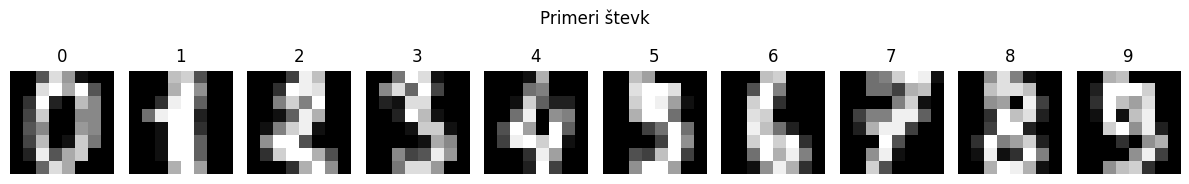

PCA pojasnjena varianca 2 komponent:
[0.14890594 0.13618771]
Skupaj: 0.2850936482369929
Epoch 500/3000, loss = 0.049806
Epoch 1000/3000, loss = 0.036539
Epoch 1500/3000, loss = 0.030935
Epoch 2000/3000, loss = 0.028551
Epoch 2500/3000, loss = 0.027122
Epoch 3000/3000, loss = 0.026065


C:\Users\Eliza.LAPTOP-V9NS83EF\AppData\Local\Temp\ipykernel_6056\2878476793.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


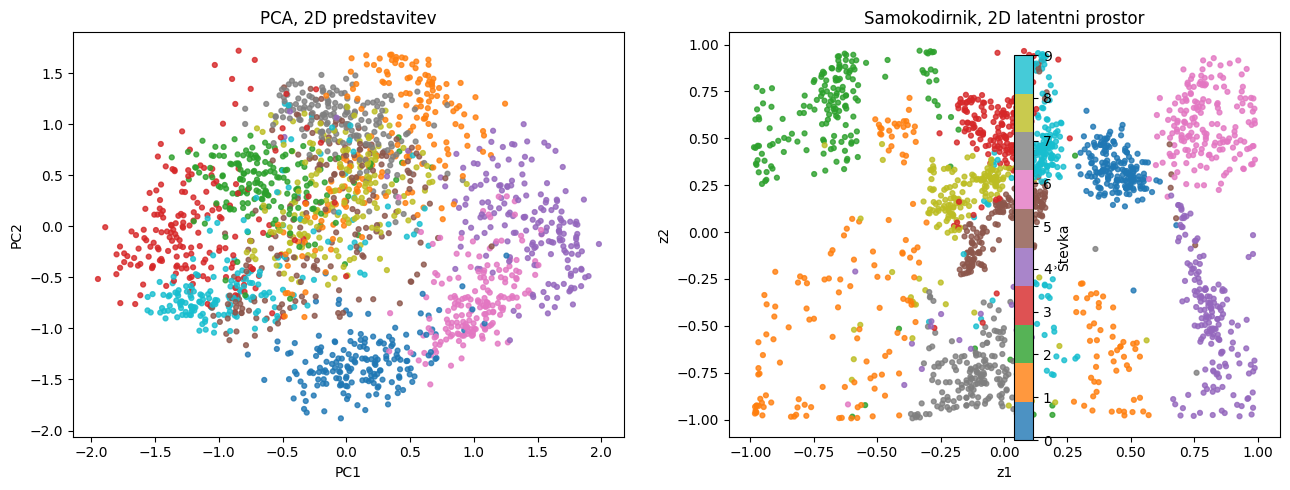

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA


# Naloži podatke
digits = load_digits()
X_digits = digits.data / 16.0       # piksli 0..16 -> 0..1
y_digits = digits.target

print(f"Število primerov: {X_digits.shape[0]}, dimenzija: {X_digits.shape[1]}")

# Prikaži po eno števko iz vsakega razreda
fig, axes = plt.subplots(1, 10, figsize=(12, 2))

for digit in range(10):
    idx = np.where(y_digits == digit)[0][0]
    axes[digit].imshow(X_digits[idx].reshape(8, 8), cmap="gray")
    axes[digit].set_title(str(digit))
    axes[digit].axis("off")

plt.suptitle("Primeri števk")
plt.tight_layout()
plt.show()

# PCA v 2D
pca_2d = PCA(n_components=2, random_state=0)
Z_pca = pca_2d.fit_transform(X_digits)

print("PCA pojasnjena varianca 2 komponent:")
print(pca_2d.explained_variance_ratio_)
print("Skupaj:", pca_2d.explained_variance_ratio_.sum())

# Samokodirnik v 2D
torch.manual_seed(0)

ae = Autoencoder(input_dim=64, latent_dim=2)

losses = train_autoencoder(
    ae,
    X_digits,
    n_epochs=3000,
    lr=2e-3,
    verbose=True
)

# pridobi latentne predstavitve
ae.eval()

X_tensor = torch.tensor(X_digits, dtype=torch.float32)

with torch.no_grad():
    X_rec, Z_ae = ae(X_tensor)

Z_ae = Z_ae.numpy()

# Scatterplot: PCA vs samokodirnik
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc1 = axes[0].scatter(
    Z_pca[:, 0],
    Z_pca[:, 1],
    c=y_digits,
    cmap="tab10",
    s=12,
    alpha=0.8
)
axes[0].set_title("PCA, 2D predstavitev")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sc2 = axes[1].scatter(
    Z_ae[:, 0],
    Z_ae[:, 1],
    c=y_digits,
    cmap="tab10",
    s=12,
    alpha=0.8
)
axes[1].set_title("Samokodirnik, 2D latentni prostor")
axes[1].set_xlabel("z1")
axes[1].set_ylabel("z2")

cbar = fig.colorbar(sc2, ax=axes, ticks=range(10))
cbar.set_label("Števka")

plt.tight_layout()
plt.show()

### 3.c: Neuravnoteženost in SMOTE — vizualno

Sedaj iz podatkovne množice števk sestavimo podatkovno množico za binarno klasifikacijo in v njej ustvarimo močno neuravnoteženost med razredoma takole. Izberemo dve podobni si števki (npr. 3 in 8) ter vzamemo zgolj 5 % primerov za eno od števk in vse primere za drugo števko. V tako dobljeni množici bo razmerje primerov v enem in drugem razredu približno $95\!:\!5$.

V tej nalogi se bomo osredotočili izključno na vizualizacijo manjšinskega razreda. Klasifikatorja ne treniramo: zanima nas, kako se porazdelitev vrednosti napovednih spremenljivk v dodanih primerih (sintetičnih primerih ali duplikatih) manjšinskega razreda ujemajo s pravo porazdelitvijo vrednosti napovednih spremenljivk v pravih primerih iz tega razreda. Slednjo ocenimo iz množice vseh pravih števk iz istega razreda, tudi tistimi, ki smo jih izpustili pri vzorčenju nove podatkovne množice.

Trije pristopi (uporabi knjižnico [imbalanced-learn](https://imbalanced-learn.org/)):
1. Brez popravkov — pustimo neuravnoteženo.
2. Naključno nadvzorčenje (`imblearn.over_sampling.RandomOverSampler`) — primere manjšinskega razreda preprosto podvajamo.
3. SMOTE (`imblearn.over_sampling.SMOTE`) — za vsak manjšinski primer poišče $k$ najbližjih sosedov istega razreda in generira sintetičen primer kot naključno interpolacijo:
$$x_{\text{nov}} = x_i + \lambda \cdot (x_{\text{sosed}} - x_i), \quad \lambda \sim \mathcal{U}(0, 1).$$

Naredi naslednje:
1. S samokodirnikom iz 3.b preslikaj v dvodimenzionalni latentni prostor naslednje primere:
   - vse prave primere manjšinskega razreda (kot referenca — to je porazdelitev, ki bi jo videli, če bi imeli vse podatke),
   - primere manjšinjskega razreda, ki smo jih vzorčili v novo podatkovno množico (tistih 5 %),
   - dodane primere (z naključnim vzorčenjem duplikatov in z uporabo SMOTE).
   Nariši tri scatter grafe enega ob drugem (vzorec / + duplilkati / + SMOTE) in jasno loči vse vrste točk, ki so za to množico aplikabilni.
2. Vizualiziraj nekaj primerov manjšinskega razreda kot $8 \times 8$ slike v štirih vrsticah: prave (neuporabljene), vzorčene, naključno vzorčeni duplikati, in sintetični SMOTE primeri.

**Vprašanji:**

- Pri SMOTE: ali so dodani sintetični primeri znotraj referenčne porazdelitve pravih manjšinskih primerov, ali izven nje? Kaj to pove o kakovosti novih sintetičnih primerov?

Sintetični primeri, dodani s SMOTE, so znotraj referenčne porazdelitve pravih manjšinskih primerov, saj so generirani kot interpolacije med obstoječimi manjšinskimi primeri. To pomeni, da SMOTE ustvarja nove primere, ki so podobni obstoječim manjšinskim primerom in se nahajajo v istem delu prostora značilnosti. To je dobra lastnost, saj kaže, da so sintetični primeri smiselni in verjetno bodo pomagali klasifikatorju bolje razumeti strukturo manjšinskega razreda. 

- SMOTE interpolira v originalnem 64-razsežnem prostoru slikovnih pik. Premisli: če bi pred SMOTE projecirali podatke v latentni prostor samokodirnika in šele tam interpolirali nove predstavitve, ki bi jih nato dekodirali nazaj v slike, bi pričakovali boljše ali slabše sintetične primere? Zakaj? (Namig: razmisli o drugem vprašanju iz 3.b — kaj se zgodi, če interpoliramo med slikama, ki ležita v različnih delih mnogoterosti smiselnih števk?)

Če bi pred SMOTE projecirali podatke v latentni prostor samokodirnika in šele tam interpolirali nove predstavitve, bi pričakovali boljše sintetične primere. To je zato, ker je latentni prostor samokodirnika strukturiran tako, da zajema smiselne značilnosti števk. Interpolacija v tem prostoru bi verjetno ustvarila nove točke, ki so še vedno smiselne kombinacije značilnosti, kar bi dekodirano nazaj v slike dalo bolj realistične števke. Vendar to ni vedno boljše. Navaden samokodirnik ni nujno dober generativni model. Latentni prostor ima lahko praznine ali območja, kjer dekodirane slike niso smiselne. Če interpoliramo med dvema osmicama, ki ležita v različnih delih latentne mnogoterosti, lahko dobimo vmesno sliko, ki je zamegljena ali podobna mešanici več števk.

In [7]:
from imblearn.over_sampling import RandomOverSampler, SMOTE
import numpy as np
import matplotlib.pyplot as plt
import torch

# 1. Izberi dva razreda in ustvari neuravnoteženo množico
CLASS_A, CLASS_B = 3, 8                  # CLASS_B bo manjšina

mask = np.isin(y_digits, [CLASS_A, CLASS_B])
X_pair = X_digits[mask]
y_pair = (y_digits[mask] == CLASS_B).astype(int)

rng = np.random.default_rng(0)

idx_majority = np.where(y_pair == 0)[0]
idx_minority_full = np.where(y_pair == 1)[0]

n_keep = int(0.05 * len(idx_majority) / 0.95)

idx_minority_keep = rng.choice(
    idx_minority_full,
    size=n_keep,
    replace=False
)

idx_minority_heldout = np.setdiff1d(idx_minority_full, idx_minority_keep)

idx_keep = np.concatenate([idx_majority, idx_minority_keep])

X_imb = X_pair[idx_keep]
y_imb = y_pair[idx_keep]

print(
    f"Vzorec: {np.bincount(y_imb)} "
    f"(vzorčili smo {n_keep} od {len(idx_minority_full)} pravih '{CLASS_B}')"
)

# Pravi manjšinski primeri
X_minority_all = X_pair[idx_minority_full]          # vsi pravi primeri števke 8
X_minority_sampled = X_pair[idx_minority_keep]      # tistih 5 %, ki smo jih obdržali
X_minority_heldout = X_pair[idx_minority_heldout]   # pravi, a neuporabljeni primeri

# 2. RandomOverSampler
ros = RandomOverSampler(random_state=0)
X_ros, y_ros = ros.fit_resample(X_imb, y_imb)

# dodani primeri so na koncu
X_ros_added = X_ros[len(X_imb):]
y_ros_added = y_ros[len(y_imb):]

# vzamemo samo dodane manjšinske primere
X_ros_added_minority = X_ros_added[y_ros_added == 1]

print("Po RandomOverSampler:", np.bincount(y_ros))
print("Dodani duplikati manjšinskega razreda:", len(X_ros_added_minority))

# 3. SMOTE
# k_neighbors mora biti manjši od števila manjšinskih primerov
k_smote = min(5, n_keep - 1)

smote = SMOTE(random_state=0, k_neighbors=k_smote)
X_smote, y_smote = smote.fit_resample(X_imb, y_imb)

# dodani sintetični primeri so na koncu
X_smote_added = X_smote[len(X_imb):]
y_smote_added = y_smote[len(y_imb):]

X_smote_added_minority = X_smote_added[y_smote_added == 1]

print("Po SMOTE:", np.bincount(y_smote))
print("Dodani SMOTE primeri manjšinskega razreda:", len(X_smote_added_minority))

# Preslikava v latentni prostor samokodirnika
def encode_with_autoencoder(model, X):
    model.eval()

    device = next(model.parameters()).device
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)

    with torch.no_grad():
        _, z = model(X_tensor)

    return z.cpu().numpy()


Z_all = encode_with_autoencoder(ae, X_minority_all)
Z_sampled = encode_with_autoencoder(ae, X_minority_sampled)
Z_ros_added = encode_with_autoencoder(ae, X_ros_added_minority)
Z_smote_added = encode_with_autoencoder(ae, X_smote_added_minority)

Vzorec: [183   9] (vzorčili smo 9 od 174 pravih '8')
Po RandomOverSampler: [183 183]
Dodani duplikati manjšinskega razreda: 174
Po SMOTE: [183 183]
Dodani SMOTE primeri manjšinskega razreda: 174


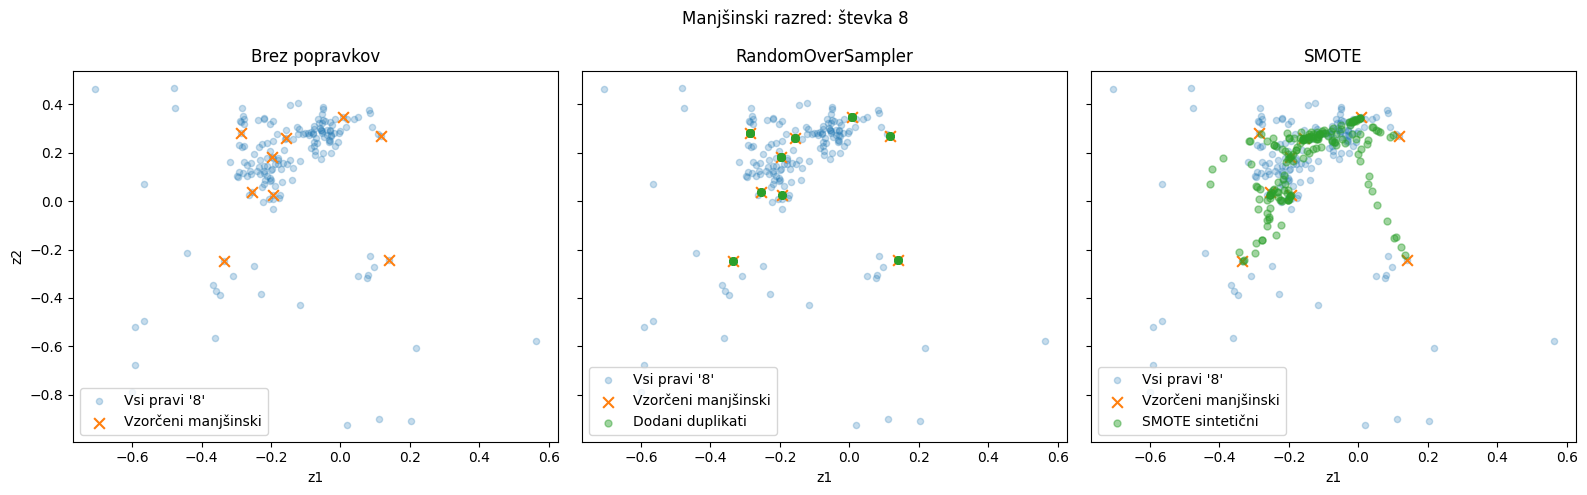

In [8]:
# Scatterplot: vzorec / duplikati / SMOTE
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True, sharey=True)

# 1. Samo neuravnoteženi vzorec
axes[0].scatter(
    Z_all[:, 0], Z_all[:, 1],
    s=20, alpha=0.25, label=f"Vsi pravi '{CLASS_B}'"
)
axes[0].scatter(
    Z_sampled[:, 0], Z_sampled[:, 1],
    s=60, marker="x", label="Vzorčeni manjšinski"
)
axes[0].set_title("Brez popravkov")
axes[0].set_xlabel("z1")
axes[0].set_ylabel("z2")
axes[0].legend()

# 2. RandomOverSampler
axes[1].scatter(
    Z_all[:, 0], Z_all[:, 1],
    s=20, alpha=0.25, label=f"Vsi pravi '{CLASS_B}'"
)
axes[1].scatter(
    Z_sampled[:, 0], Z_sampled[:, 1],
    s=60, marker="x", label="Vzorčeni manjšinski"
)
axes[1].scatter(
    Z_ros_added[:, 0], Z_ros_added[:, 1],
    s=25, alpha=0.45, label="Dodani duplikati"
)
axes[1].set_title("RandomOverSampler")
axes[1].set_xlabel("z1")
axes[1].legend()

# 3. SMOTE
axes[2].scatter(
    Z_all[:, 0], Z_all[:, 1],
    s=20, alpha=0.25, label=f"Vsi pravi '{CLASS_B}'"
)
axes[2].scatter(
    Z_sampled[:, 0], Z_sampled[:, 1],
    s=60, marker="x", label="Vzorčeni manjšinski"
)
axes[2].scatter(
    Z_smote_added[:, 0], Z_smote_added[:, 1],
    s=25, alpha=0.45, label="SMOTE sintetični"
)
axes[2].set_title("SMOTE")
axes[2].set_xlabel("z1")
axes[2].legend()

plt.suptitle(f"Manjšinski razred: števka {CLASS_B}")
plt.tight_layout()
plt.show()

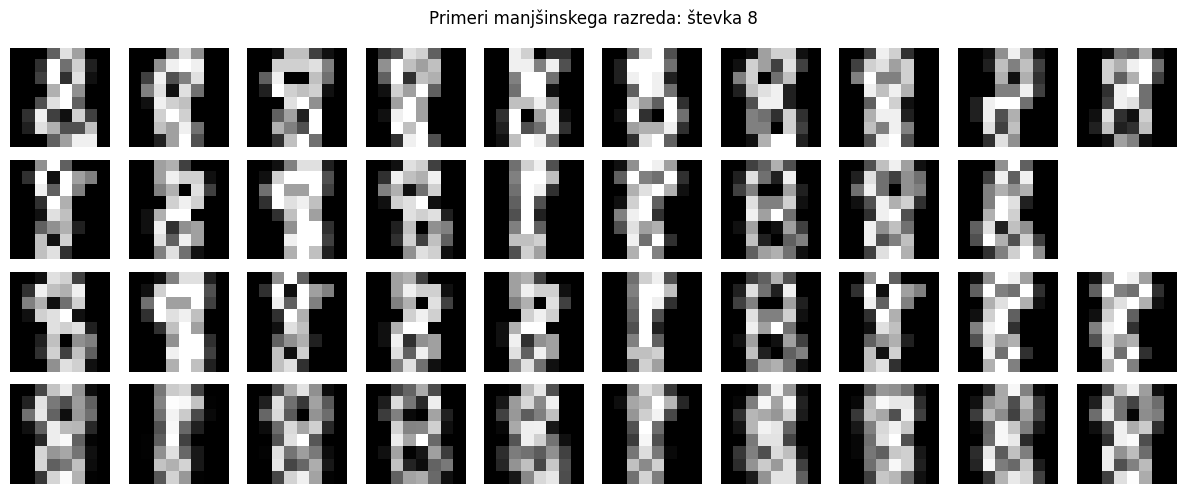

In [9]:
# Vizualizacija slik: prave / vzorčene / duplikati / SMOTE
def show_image_row(ax_row, X, title, n_show=10, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)

    ax_row[0].set_ylabel(title, rotation=0, labelpad=45, va="center")

    n_available = len(X)
    n_selected = min(n_show, n_available)

    if n_available > 0:
        selected = rng.choice(n_available, size=n_selected, replace=False)
    else:
        selected = []

    for j, ax in enumerate(ax_row):
        ax.axis("off")

        if j < n_selected:
            ax.imshow(X[selected[j]].reshape(8, 8), cmap="gray", vmin=0, vmax=1)


n_show = 10
fig, axes = plt.subplots(4, n_show, figsize=(12, 5))

show_image_row(
    axes[0],
    X_minority_heldout,
    "Prave\nneuporabljene",
    n_show=n_show,
    rng=np.random.default_rng(1)
)

show_image_row(
    axes[1],
    X_minority_sampled,
    "Vzorčene",
    n_show=n_show,
    rng=np.random.default_rng(2)
)

show_image_row(
    axes[2],
    X_ros_added_minority,
    "Duplikati",
    n_show=n_show,
    rng=np.random.default_rng(3)
)

show_image_row(
    axes[3],
    X_smote_added_minority,
    "SMOTE",
    n_show=n_show,
    rng=np.random.default_rng(4)
)

plt.suptitle(f"Primeri manjšinskega razreda: števka {CLASS_B}")
plt.tight_layout()
plt.show()

## Naloga 4: Odprta naloga

V datoteki `dn3_cracked.csv` je podana podatkovna množica, kjer primeri ustrezajo študentom. Tvoja naloga je sestaviti napovedni model, ki glede na smiselno izbrano metriko čim bolje napove, ali je študent študij končal, ga še vedno opravlja, ali je s študijem prenehal (to so vrednosti v zadnjem stolpcu z naslovom `Target`).

Celoten postopek in vse poskuse (tudi neuspešne) zabeleži in o njih poročaj.

> Pozor: Ne predpostavljaj, da so podatki čisti. Izbira mere uspešnosti, postopek delitve podatkov in obravnava razredne neuravnoteženosti so del naloge — vse svoje odločitve dobro premisli in tudi pisno utemelji v oddani rešitvi.

Podatkovna množica vsebuje naslednje spremenljivke:

- Zakonski stan: kategorični
- Vrsta vloge: kategoričen
- Vrstni red vloge: int
- Tečaj: kategoričen
- Prisotnost podnevi/zvečer: kategorična
- Prejšnja kvalifikacija: kategorična
- Prejšnja kvalifikacija (ocena): float
- Državljanstvo: kategorialno
- Materina kvalifikacija: kategorična
- Očetova kvalifikacija: kategorična
- Poklic matere: kategoričen
- Poklic očeta: kategoričen
- Ocena pri vpisu: float
- Preseljen: kategorično
- Posebne izobraževalne potrebe: kategorično
- Dolžnik: kategorično
- Šolnine do datuma: kategorično
- Spol: kategorično
- Zadnje tri številke študentske izkaznice: int
- Štipendist: kategorično
- Starost ob vpisu: int
- Tujec: kategorično
- Učne enote 1. semester (priznane): int
- Učne enote 1. semester (vpisane): int
- Učne enote 1. semester (ocene): int
- Učne enote 1. semester (odobrene): int
- Učne enote 1. semester (ocena): float
- Učne enote 1. semester (brez ocen): int
- Učne enote 2. semester (priznane): int
- Učne enote 2. semester (vpisane): int
- Učne enote 2. semester (ocene): int
- Učne enote 2. semester (odobrene): int
- Učne enote 2. semester (ocena): float
- Učne enote 2. semester (brez ocen): int
- Stopnja brezposelnosti: float
- Stopnja inflacije: float
- BDP: float
- Standardiziran rezultat sprejemnega testa: float
- Indeks socioekonomskega statusa: float
- Anketni rezultat zadovoljstva: float
- Povprečna ocena srednje šole (normalizirana): float
- Indeks oddaljenosti od fakultete: float
- Mesečni dohodek staršev (z-score): float
- Rezultat psihološkega testa A: float
- Rezultat psihološkega testa B: float
- Indeks delovne obremenitve: float
- Število ur učenja na teden (z-score): float
- Indeks digitalne pismenosti: float
- Rezultat preverjanja angleščine: float
- Ocena motivacijskega pisma: float
- Indeks zdravstvenega stanja: float
- Rezultat testa logičnega sklepanja: float
- Številka prijave: int
- Šifra mentorja: int
- Številka razreda v srednji šoli: int
- Poštna številka: int
- Šifra študijskega programa: int
- Ciljna vrednost (`Target`): kategoričen


### Namen naloge

Cilj je zgraditi model, ki na podlagi podatkov o študentih napove vrednost stolpca `Target`. 
Ker ima `Target` tri možne vrednosti (`Dropout`, `Enrolled`, `Graduate`), gre za večrazredno klasifikacijo.

### 1. Uvoz knjižnic

Najprej uvozim knjižnice za delo s podatki, predprocesiranje, delitev podatkov, prečno preverjanje, modele in mere uspešnosti.

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    make_scorer
)

from IPython.display import display

### 2. Nalaganje in prvi pregled podatkov

Podatki v datoteki so ločeni s podpičjem, zato pri branju uporabim `sep=";"`. 
Pred modeliranjem preverim velikost podatkov, ciljno spremenljivko, manjkajoče vrednosti in podvojene vrstice.

In [11]:
df = pd.read_csv("dn3_cracked.csv", sep=";")

print("Velikost podatkov:", df.shape)
display(df.head())

Velikost podatkov: (1875, 58)


,Curricular units 2nd sem (enrolled),Scholarship holder,Curricular units 2nd sem (approved),Logical reasoning test score,Debtor,Mother's occupation,Mother's qualification,Application order,Digital literacy index,Admission grade,...,High school class number,Satisfaction survey score,Previous qualification,Age at enrollment,English proficiency test score,Postal code,Workload index,Educational special needs,Unemployment rate,Target
0,NaN,0.0,0.0,1.029202,0.0,4.0,1.0,2.0,0.497645,115.2,...,64857,-0.041278,1.0,21.0,-1.518980,16423,0.155148,1.0,15.5,Dropout
1,8.0,1.0,0.0,0.825069,NaN,9.0,19.0,1.0,-0.116446,125.8,...,79290,-1.053710,1.0,20.0,-0.536819,26941,0.386800,0.0,9.4,Enrolled
2,6.0,0.0,0.0,0.321814,0.0,9.0,19.0,2.0,2.255744,122.8,...,40883,-0.400564,NaN,19.0,1.384662,53610,0.499483,0.0,12.4,Dropout
3,NaN,0.0,2.0,0.232663,0.0,9.0,38.0,3.0,1.159216,127.3,...,69679,-0.675953,1.0,19.0,0.220975,11437,-0.343901,0.0,12.7,Dropout
4,8.0,NaN,8.0,-0.036289,0.0,3.0,NaN,1.0,0.816734,142.8,...,69075,-0.796558,NaN,18.0,-0.774695,62987,0.183969,0.0,NaN,Graduate


In [12]:
print("Porazdelitev razredov v Target:")
display(df["Target"].value_counts())

print("Deleži razredov v Target:")
display(df["Target"].value_counts(normalize=True))

Porazdelitev razredov v Target:


Target
Dropout     1406
Enrolled     375
Graduate      94
Name: count, dtype: int64

Deleži razredov v Target:


Target
Dropout     0.749867
Enrolled    0.200000
Graduate    0.050133
Name: proportion, dtype: float64

In [13]:
print("Število manjkajočih vrednosti po stolpcih:")
display(df.isna().sum().sort_values(ascending=False))

print("Število podvojenih vrstic:")
display(df.duplicated().sum())

print("Število manjkajočih vrednosti v Target:")
display(df["Target"].isna().sum())

Število manjkajočih vrednosti po stolpcih:


Admission grade                                   225
Daytime/evening attendance                        223
Curricular units 2nd sem (credited)               222
Curricular units 2nd sem (enrolled)               221
Curricular units 1st sem (grade)                  220
Curricular units 2nd sem (evaluations)            219
Course                                            218
Gender                                            217
Application mode                                  216
Father's qualification                            215
Scholarship holder                                214
Curricular units 2nd sem (approved)               214
Educational special needs                         213
Inflation rate                                    213
Marital status                                    213
Curricular units 2nd sem (grade)                  213
Curricular units 1st sem (enrolled)               213
International                                     213
Curricular units 1st sem (cr

Število podvojenih vrstic:


np.int64(0)

Število manjkajočih vrednosti v Target:


np.int64(0)

### Komentar prvega pregleda

Podatkovna množica vsebuje 1875 primerov in 58 stolpcev. Ciljna spremenljivka `Target` ima tri razrede: `Dropout`, `Enrolled` in `Graduate`.

Razredi so neuravnoteženi: največ je primerov razreda `Dropout`, precej manj je primerov `Enrolled`, najmanj pa je primerov `Graduate`. 
Zaradi tega se pri primerjavi modelov osredotočim na **precision**, **recall** in **F1**, ne samo na eno splošno mero.

Podatki vsebujejo precej manjkajočih vrednosti, zato vrstic z manjkajočimi vrednostmi ne odstranim. 
Namesto tega manjkajoče vrednosti obravnavam v predprocesiranju: pri numeričnih stolpcih uporabim mediano, pri kategoričnih pa najpogostejšo vrednost.

### 3. Priprava stolpcev

Nekateri stolpci so podobni identifikatorjem oziroma šifram. Takšni stolpci lahko povzročijo, da se model uči naključnih oznak namesto splošnih vzorcev, zato jih v prvem modeliranju izločim.

Kategorične stolpce posebej naštejem, preostale uporabljene stolpce pa obravnavam kot numerične.

In [14]:
target_col = "Target"

id_like_cols = [
    "Application number",
    "Mentor code",
    "Last three digits of the ID",
    "High school class number",
    "Postal code",
    "Study program code"
]

categorical_cols = [
    "Marital status",
    "Application mode",
    "Course",
    "Daytime/evening attendance",
    "Previous qualification",
    "Nationality",
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    "Displaced",
    "Educational special needs",
    "Debtor",
    "Tuition fees up to date",
    "Gender",
    "Scholarship holder",
    "International"
]

# Uporabim samo stolpce, ki so dejansko prisotni v podatkih.
id_like_cols = [col for col in id_like_cols if col in df.columns]
categorical_cols = [col for col in categorical_cols if col in df.columns]

X = df.drop(columns=[target_col] + id_like_cols)
y = df[target_col]

numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Število uporabljenih numeričnih stolpcev:", len(numeric_cols))
print("Število uporabljenih kategoričnih stolpcev:", len(categorical_cols))
print("Izločeni stolpci:")
display(id_like_cols)

Število uporabljenih numeričnih stolpcev: 34
Število uporabljenih kategoričnih stolpcev: 17
Izločeni stolpci:


['Application number',
 'Mentor code',
 'Last three digits of the ID',
 'High school class number',
 'Postal code',
 'Study program code']

### 4. Predprocesiranje podatkov

Za numerične stolpce uporabim:
- zapolnjevanje manjkajočih vrednosti z mediano,
- standardizacijo.

Za kategorične stolpce uporabim:
- zapolnjevanje manjkajočih vrednosti z najpogostejšo vrednostjo,
- kodiranje z `OneHotEncoder`.

Predprocesiranje dam v `Pipeline`, da se vsi koraki naučijo samo na učnih podatkih in ne na testnih.

In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

### 5. Delitev podatkov

Podatke razdelim na učno in testno množico. 
Ker so razredi v `Target` neuravnoteženi, uporabim stratificirano delitev, da se razmerja med razredi približno ohranijo v obeh množicah.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Učna množica:", X_train.shape)
print("Testna množica:", X_test.shape)

print("Porazdelitev razredov v učni množici:")
display(y_train.value_counts(normalize=True))

print("Porazdelitev razredov v testni množici:")
display(y_test.value_counts(normalize=True))

Učna množica: (1500, 51)
Testna množica: (375, 51)
Porazdelitev razredov v učni množici:


Target
Dropout     0.75
Enrolled    0.20
Graduate    0.05
Name: proportion, dtype: float64

Porazdelitev razredov v testni množici:


Target
Dropout     0.749333
Enrolled    0.200000
Graduate    0.050667
Name: proportion, dtype: float64

### 6. Izbor modelov

Uporabim naslednje modele:

- logistična regresija,
- odločitveno drevo,
- naključni gozd,
- SVM.

Ker je ciljna spremenljivka neuravnotežena, pri modelih uporabim `class_weight="balanced"`, kjer je to mogoče. 
S tem model redkejšim razredom pripiše večjo težo.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "SVM": LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=10000
    )
}

### 7. Prečno preverjanje

Za primerjavo modelov uporabim 5-kratno stratificirano prečno preverjanje na učni množici. 
Primerjam precision, recall in F1 z uteženim povprečenjem.

Parameter `zero_division=0` pomeni, da se v primeru, ko model nekega razreda sploh ne napove, nedefinirana vrednost nastavi na 0. 
Parameter `pos_label=None` je dodan zato, ker imamo večrazredni problem z besedilnimi oznakami razredov.

In [18]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "precision": make_scorer(
        precision_score,
        average="weighted",
        zero_division=0,
        pos_label=None
    ),
    "recall": make_scorer(
        recall_score,
        average="weighted",
        zero_division=0,
        pos_label=None
    ),
    "f1": make_scorer(
        f1_score,
        average="weighted",
        zero_division=0,
        pos_label=None
    )
}

In [19]:
results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1", ascending=False).reset_index(drop=True)

display(results_df)

,Model,Precision,Recall,F1
0,SVM,0.778135,0.748000,0.759997
1,Logistic Regression,0.780519,0.703333,0.730215
2,Decision Tree,0.695514,0.691333,0.692808
3,Random Forest,0.666947,0.752667,0.657574


### Komentar primerjave modelov

Modele primerjam predvsem po vrednosti F1, ker ta hkrati upošteva precision in recall. 
S tem se izognem izbiri modela, ki bi bil dober samo po eni meri.

Po prečnem preverjanju se kot najboljši model izbere tisti z najvišjo vrednostjo F1. 
V nadaljevanju ta model naučim na celotni učni množici in ga nato ocenim še na testni množici.

### 8. Končni model in vrednotenje na testni množici

Najboljši model izberem na podlagi rezultata F1 pri prečnem preverjanju. 
Testno množico uporabim šele na koncu, da dobim bolj pošteno oceno delovanja izbranega modela na novih podatkih.

In [20]:
best_model_name = results_df.loc[0, "Model"]
print("Najboljši model po F1 pri prečnem preverjanju:", best_model_name)

best_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", models[best_model_name])
])

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

Najboljši model po F1 pri prečnem preverjanju: SVM


In [21]:
test_results = pd.DataFrame({
    "Precision": [precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
        pos_label=None
    )],
    "Recall": [recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
        pos_label=None
    )],
    "F1": [f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0,
        pos_label=None
    )]
}, index=[best_model_name])

display(test_results)

,Precision,Recall,F1
SVM,0.769771,0.749333,0.758329


Poleg povprečnih vrednosti pogledam še rezultate po posameznih razredih. 
To je pomembno zato, ker je razred `Graduate` precej redek in ga lahko nekateri modeli napovedujejo slabše.

In [22]:
labels = list(best_model.named_steps["model"].classes_)

report = classification_report(
    y_test,
    y_pred,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Izpišem samo razrede in uteženo povprečje, brez dodatnih vrstic.
rows_to_show = labels + ["weighted avg"]
report_df = report_df.loc[rows_to_show, ["precision", "recall", "f1-score", "support"]]

display(report_df)

,precision,recall,f1-score,support
Dropout,0.886792,0.836299,0.860806,281.0
Enrolled,0.471264,0.546667,0.506173,75.0
Graduate,0.217391,0.263158,0.238095,19.0
weighted avg,0.769771,0.749333,0.758329,375.0


Matrika zamenjav pokaže, kje se model najpogosteje zmoti. 
Vrstice predstavljajo dejanske razrede, stolpci pa napovedane razrede.

In [23]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

cm_df = pd.DataFrame(
    cm,
    index=[f"dejanski {label}" for label in labels],
    columns=[f"napovedani {label}" for label in labels]
)

display(cm_df)

,napovedani Dropout,napovedani Enrolled,napovedani Graduate
dejanski Dropout,235,36,10
dejanski Enrolled,26,41,8
dejanski Graduate,4,10,5


### 9. Zaključek

V nalogi sem preizkusila štiri modele: logistično regresijo, odločitveno drevo, naključni gozd in SVM. 
Vse modele sem primerjala s stratificiranim prečnim preverjanjem na učni množici.

Za vrednotenje sem uporabila precision, recall in F1. 
Zaradi neuravnoteženih razredov sem uporabila uteženo povprečenje, pri modelih pa nastavitev `class_weight="balanced"`.

Na koncu sem najboljši model po F1 naučila na celotni učni množici in ga ocenila na testni množici. 
Pri interpretaciji rezultatov je treba posebej paziti na razred `Graduate`, ker ima najmanj primerov in je zato najtežji za napovedovanje.